# Notebook 06 — Temporal Evaluation: All 14 Model Variants

## What this notebook does

Trains every model variant on the **standard temporal split** — the same design
used in notebooks 03, 03e, and 03f — and records the temporal holdout F1 (`Temp.F1`)
for each. This fills in the `n/a` column in notebook 05's comparison table.

## Why a separate notebook?

Notebook 05 evaluates *spatial* generalisation (hold out geography, predict future).
This notebook evaluates *temporal* generalisation (use all geography, predict future).
The two questions are complementary:
- `Temp.F1`: "How good is this model at predicting the next 6 months within Myanmar?"
- `H F1`:    "How good is this model at predicting control in regions it never trained on?"

## Experimental design

- **Training:** all labelled cells, months ≤ 2025-09 (23 months)
- **Validation:** all labelled cells, months > 2025-09 (6 months: Oct 2025 – Mar 2026)
- **No geographic holdout** — all 149 cells (inner-join) or 185 cells (Felipe) used
- **TRAIN_CUTOFF = '2025-09'** for ALL models (standardised for fair comparison)

## Models covered

| Model | Status | Action |
|---|---|---|
| v1_frozen_10ch | checkpoint exists | load, evaluate |
| v_nofrozen_10ch | checkpoint exists | load, evaluate |
| v_allfeatures_43ch | checkpoint exists | load, evaluate |
| all other 11 variants | no checkpoint | train (200 ep), save, evaluate |

## Output

`data/processed/temporal_comparison/temporal_results.csv` — one row per model,
with accuracy, macro F1, and per-class F1 scores.

## Cell 0 — Configuration

Identical constants to notebook 05. MODEL_CONFIGS and feature lists copied
verbatim so results are directly comparable. The only addition is
`EXISTING_CHECKPOINTS` — paths to the three models already trained in
notebooks 03 / 03e / 03f.

In [27]:
# ── CELL 0: Configuration ─────────────────────────────────────────────────────
import random, numpy as np, torch, os, time                # core libraries
from pathlib import Path                                    # file path handling
import pandas as pd                                        # dataframe operations

SEED = 20269999                                            # project-wide seed

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)  # fix all rngs
torch.cuda.manual_seed_all(SEED)                           # fix CUDA rng
if hasattr(torch.backends, "mps"):                        # fix MPS rng (Apple Silicon)
    torch.mps.manual_seed(SEED) if hasattr(torch.mps, "manual_seed") else None
torch.backends.cudnn.deterministic = True                  # reproducible cuDNN
torch.backends.cudnn.benchmark = False                     # no auto-tuning
os.environ["PYTHONHASHSEED"] = str(SEED)                  # fix Python hash seed

if not Path("data").exists():                              # ensure cwd is project root
    os.chdir(Path(".").resolve().parent)
PROJECT_ROOT = Path(".").resolve()                         # absolute project root path
DATA_PROC    = PROJECT_ROOT / "data" / "processed"         # processed data folder
MODELS_DIR   = PROJECT_ROOT / "models" / "temporal"        # temporal checkpoint folder
RESULTS_DIR  = PROJECT_ROOT / "data" / "processed" / "temporal_comparison"
MODELS_DIR.mkdir(exist_ok=True)                            # create if not exists
RESULTS_DIR.mkdir(exist_ok=True)                           # create if not exists

# ── Constants (identical to notebook 05) ─────────────────────────────────────
LABEL_MAP    = {"gov": 0, "opo": 1, "uncertain": 2}       # class name → index
TRAIN_CUTOFF = "2025-09"                                   # last training month (inclusive)
VAL_MONTHS   = ["2025-10","2025-11","2025-12",            # 6 temporal holdout months
                "2026-01","2026-02","2026-03"]
NUM_CLASSES  = 3                                           # gov / opo / uncertain
BATCH_SIZE   = 8                                           # samples per training batch
NUM_EPOCHS   = 200                                         # training epochs per model
BASE_LR      = 1e-4                                        # decoder learning rate
ENCODER_LR   = 1e-5                                        # encoder learning rate (lower)
PHASE1_END   = 30                                          # epochs with encoder frozen
FOCAL_OUT_WEIGHT = 0.0                                     # CE weight outside focal mask
NEIGHBOR_RADIUS  = 1                                       # focal mask dilation radius
PAD_H, PAD_W = 40, 16                                     # raster dimensions (padded to 8)

# ── Feature lists (identical to notebook 05) ─────────────────────────────────
INPUT_FEATURES_10 = [
    "total_events", "total_fatalities", "events_gov", "events_nug",
    "events_ula", "events_kio", "gov_vs_civilians", "gov_event_share",
    "total_events_lag1", "total_fatalities_lag1",
]                                                          # 10 hand-selected UCDP features

INPUT_FEATURES_43 = [
    "total_events", "is_statebased", "is_onesided", "gov_vs_civilians",
    "total_fatalities", "deaths_a", "deaths_b", "deaths_civilians",
    "events_gov", "events_nug", "events_kio", "events_ula", "events_knu",
    "events_mndaa", "events_pslf", "events_cnf", "events_rcss", "events_uwsa",
    "n_unique_dyads",
    "total_events_lag1", "total_fatalities_lag1", "events_gov_lag1",
    "events_nug_lag1", "gov_vs_civilians_lag1", "is_onesided_lag1",
    "total_events_lag3", "total_fatalities_lag3", "events_gov_lag3",
    "events_nug_lag3", "gov_vs_civilians_lag3", "is_onesided_lag3",
    "total_events_lag6", "total_fatalities_lag6", "events_gov_lag6",
    "events_nug_lag6", "gov_vs_civilians_lag6", "is_onesided_lag6",
    "total_events_roll3m", "total_fatalities_roll3m",
    "total_events_roll6m", "total_fatalities_roll6m",
    "gov_event_share", "nug_event_share",
]                                                          # all 43 UCDP numeric features

PRIOGRID_FEATURES = [
    "mountains_mean", "ttime_mean", "forest_gc", "agri_gc",  # terrain
    "bdist1", "capdist",                                  # distance measures
    "nlights_mean", "pop_gpw_sum",                        # population/economic
    "gem_s", "petroleum_s", "diamsec_s",                  # natural resources
]                                                          # 11 PRIOGRID catalog features

INPUT_FEATURES_10_ENRICHED = INPUT_FEATURES_10 + PRIOGRID_FEATURES  # 10+11 = 21
INPUT_FEATURES_43_ENRICHED = INPUT_FEATURES_43 + PRIOGRID_FEATURES  # 43+11 = 54

# ── Existing checkpoints (trained in notebooks 03 / 03e / 03f) ───────────────
# These three models already have Temp.F1 — load checkpoint, skip training.
EXISTING_CHECKPOINTS = {
    "v1_frozen_10ch":     PROJECT_ROOT / "models" / "unet_v1_ch10_ep200.pt",
    "v_nofrozen_10ch":    PROJECT_ROOT / "models" / "unet_v_nofrozen.pt",
    "v_allfeatures_43ch": PROJECT_ROOT / "models" / "unet_v_allfeatures.pt",
}                                                          # maps model name → checkpoint path

# ── Known Temp.F1 values (for cross-reference and validation) ─────────────────
KNOWN_TEMP_F1 = {
    "v1_frozen_10ch":     0.899,                          # from notebook 03
    "v_nofrozen_10ch":    0.895,                          # from notebook 03e
    "v_allfeatures_43ch": 0.923,                          # from notebook 03f
}                                                          # used to verify loaded checkpoints

# ── Feature sets dict (for raster builder) ────────────────────────────────────
# Keys = n_channels, values = feature list. Built BEFORE any loop that uses it.
FEATURE_SETS = {
    10:                              INPUT_FEATURES_10,
    43:                              INPUT_FEATURES_43,
    len(INPUT_FEATURES_10_ENRICHED): INPUT_FEATURES_10_ENRICHED,  # 21
    len(INPUT_FEATURES_43_ENRICHED): INPUT_FEATURES_43_ENRICHED,  # 54
}                                                          # covers all 4 channel counts

LJ_FEATURE_SETS = {
    10:                              INPUT_FEATURES_10,
    43:                              INPUT_FEATURES_43,
    len(INPUT_FEATURES_10_ENRICHED): INPUT_FEATURES_10_ENRICHED,
    len(INPUT_FEATURES_43_ENRICHED): INPUT_FEATURES_43_ENRICHED,
}                                                          # same as FEATURE_SETS for LJ

# ── Model configurations (identical to notebook 05) ──────────────────────────
MODEL_CONFIGS = [
    {"name": "v1_frozen_10ch",     "features": INPUT_FEATURES_10,           "n_channels": 10, "freeze": True,  "description": "Baseline — frozen encoder (30ep), inner join, 10 features"},
    {"name": "v_nofrozen_10ch",    "features": INPUT_FEATURES_10,           "n_channels": 10, "freeze": False, "description": "Mihai — discriminative LR, inner join, 10 features"},
    {"name": "v_allfeatures_43ch", "features": INPUT_FEATURES_43,           "n_channels": 43, "freeze": False, "description": "All UCDP features — discriminative LR, inner join, 43 features"},
    {"name": "v_felipe_focal",     "features": INPUT_FEATURES_10,           "n_channels": 10, "freeze": True,  "description": "Felipe — left join, focal CE, frozen (30ep), 10 features", "data_type": "left_join_focal"},
    {"name": "v_felipe_nofrozen",  "features": INPUT_FEATURES_10,           "n_channels": 10, "freeze": False, "description": "Felipe — left join, focal CE, discrim LR, 10 features",   "data_type": "left_join_focal"},
    {"name": "v_felipe_frozen_43ch",     "features": INPUT_FEATURES_43,     "n_channels": 43, "freeze": True,  "description": "Felipe — left join, focal CE, frozen (30ep), 43 features", "data_type": "left_join_focal"},
    {"name": "v_felipe_nofrozen_43ch",   "features": INPUT_FEATURES_43,     "n_channels": 43, "freeze": False, "description": "Felipe — left join, focal CE, discrim LR, 43 features",   "data_type": "left_join_focal"},
    {"name": "v1_frozen_terrain",         "features": INPUT_FEATURES_10_ENRICHED, "n_channels": len(INPUT_FEATURES_10_ENRICHED), "freeze": True,  "description": "v1 frozen + PRIOGRID terrain (21ch)"},
    {"name": "v_nofrozen_terrain",        "features": INPUT_FEATURES_10_ENRICHED, "n_channels": len(INPUT_FEATURES_10_ENRICHED), "freeze": False, "description": "v_nofrozen + PRIOGRID terrain (21ch)"},
    {"name": "v_allfeatures_terrain",     "features": INPUT_FEATURES_43_ENRICHED, "n_channels": len(INPUT_FEATURES_43_ENRICHED), "freeze": False, "description": "v_allfeatures + PRIOGRID terrain (54ch)"},
    {"name": "v_felipe_focal_terrain",    "features": INPUT_FEATURES_10_ENRICHED, "n_channels": len(INPUT_FEATURES_10_ENRICHED), "freeze": True,  "description": "Felipe focal — left join, focal CE, frozen (30ep), 21ch terrain",   "data_type": "left_join_focal"},
    {"name": "v_felipe_nofrozen_terrain", "features": INPUT_FEATURES_10_ENRICHED, "n_channels": len(INPUT_FEATURES_10_ENRICHED), "freeze": False, "description": "Felipe focal — left join, focal CE, discrim LR, 21ch terrain",       "data_type": "left_join_focal"},
    {"name": "v_felipe_frozen_43ch_terrain",   "features": INPUT_FEATURES_43_ENRICHED, "n_channels": len(INPUT_FEATURES_43_ENRICHED), "freeze": True,  "description": "Felipe focal — left join, focal CE, frozen (30ep), 54ch terrain", "data_type": "left_join_focal"},
    {"name": "v_felipe_nofrozen_43ch_terrain", "features": INPUT_FEATURES_43_ENRICHED, "n_channels": len(INPUT_FEATURES_43_ENRICHED), "freeze": False, "description": "Felipe focal — left join, focal CE, discrim LR, 54ch terrain",     "data_type": "left_join_focal"},
    # ── Left-join standard CE+Dice variants (add after v_allfeatures_43ch_lj) ──
    {"name": "v1_frozen_10ch_lj",     "features": INPUT_FEATURES_10, "n_channels": 10, "freeze": True,  "data_type": "left_join", "description": "v1 frozen — LJ 185 cells, standard CE+Dice, 10 features"},
    {"name": "v_nofrozen_10ch_lj",    "features": INPUT_FEATURES_10, "n_channels": 10, "freeze": False, "data_type": "left_join", "description": "v_nofrozen — LJ 185 cells, standard CE+Dice, 10 features"},
    {"name": "v_allfeatures_43ch_lj", "features": INPUT_FEATURES_43, "n_channels": 43, "freeze": False, "data_type": "left_join", "description": "v_allfeatures — LJ 185 cells, standard CE+Dice, 43 features"},
    # ── Missing combinations: all 43 features WITH frozen encoder ─────────────
    {"name": "v_allfeatures_43ch_frozen", "features": INPUT_FEATURES_43, "n_channels":  43, "freeze": True, "data_type": "inner_join", "description": "All 43 features — frozen encoder (30ep), inner join"},
    {"name": "v_allfeatures_43ch_frozen_lj", "features": INPUT_FEATURES_43, "n_channels":  43, "freeze": True, "data_type": "left_join", "description": "All 43 features — frozen encoder (30ep), left join 185 cells"},
]                                                          

print(f"✅ Seed fixed: {SEED}")
print(f"   Train cutoff: {TRAIN_CUTOFF}  |  Val months: {len(VAL_MONTHS)}")
print(f"   Models: {len(MODEL_CONFIGS)}  |  Feature sets: {list(FEATURE_SETS.keys())} channels")
print(f"   Checkpoints → {MODELS_DIR}")
print(f"   Results    → {RESULTS_DIR}")

✅ Seed fixed: 20269999
   Train cutoff: 2025-09  |  Val months: 6
   Models: 19  |  Feature sets: [10, 43, 21, 54] channels
   Checkpoints → /Users/tizianschenk/Documents/BSE/MasterProject/territorial_control_dsdm_master_project/models/temporal
   Results    → /Users/tizianschenk/Documents/BSE/MasterProject/territorial_control_dsdm_master_project/data/processed/temporal_comparison


## Cell 1 — Load data and build rasters (inner-join models)

Simpler than notebook 05 — no k-means blocks, no fold assignments.
Builds X_arrays for all 4 channel counts (10, 43, 21, 54).
m_train and m_val cover ALL labelled cells — no geographic holdout.

Uses `myanmar_priogrid_features_enriched.csv` so all 14 models
(including terrain variants) can access their features from the same file.

In [28]:
# ── CELL 1: Load data and build rasters (inner-join) ─────────────────────────
import pandas as pd, numpy as np                            # dataframe and array ops
import torch, torch.nn as nn, torch.optim as optim         # deep learning
from torch.utils.data import Dataset, DataLoader           # data loading
import segmentation_models_pytorch as smp                  # U-Net with ResNet encoder
from sklearn.metrics import accuracy_score, f1_score       # evaluation metrics

# ── 1.1 Load feature matrix and target variable ───────────────────────────────
target   = pd.read_parquet(DATA_PROC / "10_target_variable.parquet")       # ground truth labels
features = pd.read_csv(DATA_PROC / "myanmar_priogrid_features_enriched.csv") # enriched feature matrix
target["target_int"]   = target["target"].map(LABEL_MAP)  # map class names to integers
target["year_month"]   = target["year_month"].astype(str)  # ensure string format
features["year_month"] = features["year_month"].astype(str)# ensure string format

# Inner join: keep only cells with both features and labels
labelled = features.merge(
    target[["priogrid_gid","year_month","target","target_int"]],
    on=["priogrid_gid","year_month"], how="inner"
).sort_values(["priogrid_gid","year_month"]).reset_index(drop=True)

print(f"Inner join: {len(labelled):,} rows | "
      f"{labelled['priogrid_gid'].nunique()} cells | "
      f"{labelled['year_month'].nunique()} months")

# ── 1.2 PRIOGRID coordinate system → raster positions ────────────────────────
all_gids    = features["priogrid_gid"].unique()            # all cells in feature matrix
global_rows = (all_gids - 1) // 720                        # PRIOGRID global row index
global_cols = (all_gids - 1) % 720                         # PRIOGRID global col index
min_gr, max_gr = global_rows.min(), global_rows.max()      # Myanmar bounding box (rows)
min_gc, max_gc = global_cols.min(), global_cols.max()      # Myanmar bounding box (cols)

gid_to_local = {                                           # map cell ID → (row, col) in raster
    int(gid): {"r": int((gid-1)//720 - min_gr),
               "c": int((gid-1)%720  - min_gc)}
    for gid in all_gids
}

# ── 1.3 Month index splits ────────────────────────────────────────────────────
month_keys = sorted(labelled["year_month"].unique())       # all 29 months in order
train_idx  = [i for i, m in enumerate(month_keys) if m <= TRAIN_CUTOFF]  # indices of train months
val_idx    = [i for i, m in enumerate(month_keys) if m >  TRAIN_CUTOFF]  # indices of val months
print(f"Train months: {len(train_idx)} | Val months: {len(val_idx)}")

# ── 1.4 Normalisation stats — training rows only ──────────────────────────────
train_rows = labelled[labelled["year_month"] <= TRAIN_CUTOFF]  # training rows only
norm_stats = {}                                            # dict: n_ch → feature → {mean, std}
for n_ch, feat_list in FEATURE_SETS.items():              # one stat dict per channel count
    norm_stats[n_ch] = {
        f: {"mean": float(train_rows[f].mean()),
            "std":  float(train_rows[f].std())}
        for f in feat_list                                 # mean and std for each feature
    }
for n_ch in FEATURE_SETS:
    print(f"  Norm stats {n_ch}-ch: {len(norm_stats[n_ch])} features")

# ── 1.5 Build rasters for all channel counts ──────────────────────────────────
X_lists  = {n: [] for n in FEATURE_SETS}                  # one list per channel count
y_list, m_list = [], []                                    # shared labels and masks

for month in month_keys:                                   # iterate all 29 months
    month_data = labelled[labelled["year_month"] == month] # rows for this month

    y_raster = np.full((PAD_H, PAD_W), -1, dtype=np.int64)  # initialise label raster
    m_raster = np.zeros((PAD_H, PAD_W), dtype=np.float32)   # initialise mask raster

    for _, row in month_data.iterrows():                   # fill y and m for each cell
        gid = int(row["priogrid_gid"])
        if gid not in gid_to_local: continue
        r = gid_to_local[gid]["r"]; c = gid_to_local[gid]["c"]
        if pd.notna(row["target_int"]):
            y_raster[r, c] = int(row["target_int"])        # true class label
            m_raster[r, c] = 1.0                           # mark as labelled
    y_list.append(y_raster); m_list.append(m_raster)

    for n_ch, feat_list in FEATURE_SETS.items():           # one X raster per channel count
        X_raster = np.zeros((n_ch, PAD_H, PAD_W), dtype=np.float32)
        stats    = norm_stats[n_ch]                        # use pre-computed training stats
        for _, row in month_data.iterrows():
            gid = int(row["priogrid_gid"])
            if gid not in gid_to_local: continue
            r = gid_to_local[gid]["r"]; c = gid_to_local[gid]["c"]
            for ch, feat in enumerate(feat_list):          # z-score normalise each channel
                raw = row.get(feat, np.nan)
                X_raster[ch, r, c] = (
                    0.0 if (isinstance(raw, float) and np.isnan(raw))
                    else (raw - stats[feat]["mean"]) / (stats[feat]["std"] + 1e-8)
                )
        X_lists[n_ch].append(X_raster)

# ── 1.6 Stack and split ───────────────────────────────────────────────────────
X_arrays = {n: np.stack(lst) for n, lst in X_lists.items()}  # (29, n_ch, 40, 16)
y_array  = np.stack(y_list)                                # (29, 40, 16)
m_base   = np.stack(m_list)                                # (29, 40, 16)

X_train  = {n: X_arrays[n][train_idx] for n in FEATURE_SETS}  # training months
X_val    = {n: X_arrays[n][val_idx]   for n in FEATURE_SETS}  # validation months
y_train  = y_array[train_idx];  y_val  = y_array[val_idx]  # training / val labels
m_train  = m_base[train_idx];   m_val  = m_base[val_idx]   # training / val masks

print(f"\nRasters built:")
for n in FEATURE_SETS:
    print(f"  X_arrays[{n}]: {X_arrays[n].shape}")
print(f"  y_array: {y_array.shape}  |  m_base: {m_base.shape}")
print(f"  m_train labelled cell-months: {int(m_train.sum()):,}")
print(f"  m_val   labelled cell-months: {int(m_val.sum()):,}")
print(f"\n✅ Cell 1 complete")

Inner join: 4,229 rows | 149 cells | 29 months
Train months: 23 | Val months: 6
  Norm stats 10-ch: 10 features
  Norm stats 43-ch: 43 features
  Norm stats 21-ch: 21 features
  Norm stats 54-ch: 54 features

Rasters built:
  X_arrays[10]: (29, 10, 40, 16)
  X_arrays[43]: (29, 43, 40, 16)
  X_arrays[21]: (29, 21, 40, 16)
  X_arrays[54]: (29, 54, 40, 16)
  y_array: (29, 40, 16)  |  m_base: (29, 40, 16)
  m_train labelled cell-months: 3,335
  m_val   labelled cell-months: 894

✅ Cell 1 complete


## Cell 2 — Left-join data (Felipe models)

Builds rasters for all 4 channel counts using the left-join approach:
185 cells (149 inner-join + 36 quiet cells with zero UCDP events).
No fold masking needed here — all LJ cells used for training, all for eval.

Focal mask is also built here (needed by the focal loss function in Cell 3).

In [29]:
# ── CELL 2: Left-join data and focal mask (Felipe models) ─────────────────────
from scipy.ndimage import binary_dilation                  # for focal mask dilation

# ── 2.1 Left join FROM target ─────────────────────────────────────────────────
labelled_lj = target[["priogrid_gid","year_month","target"]].merge(
    features, on=["priogrid_gid","year_month"], how="left"  # left keeps all 185 labelled cells
)
labelled_lj["target_int"] = labelled_lj["target"].map(LABEL_MAP)  # integer class labels
for feat_list in LJ_FEATURE_SETS.values():                # fill NaN for all feature sets
    labelled_lj[feat_list] = labelled_lj[feat_list].fillna(0.0)  # quiet cells get 0.0

print(f"LJ cells: {labelled_lj['priogrid_gid'].nunique()} "
      f"(+{labelled_lj['priogrid_gid'].nunique() - labelled['priogrid_gid'].nunique()} recovered)")

# ── 2.2 Extend gid_to_local to 185 cells ─────────────────────────────────────
gid_to_local_lj = dict(gid_to_local)                      # copy inner-join mapping
for gid in labelled_lj["priogrid_gid"].unique():
    if gid not in gid_to_local_lj:                        # compute position for extra cells
        gr = (gid - 1) // 720;  gc = (gid - 1) % 720
        lr = gr - min_gr;        lc = gc - min_gc
        if 0 <= lr < PAD_H and 0 <= lc < PAD_W:
            gid_to_local_lj[gid] = {"r": lr, "c": lc}    # add to mapping if in raster bounds

# ── 2.3 LJ normalisation stats — training rows only ──────────────────────────
lj_norm_stats = {}                                         # dict: n_ch → feature → {mean, std}
lj_train_rows = labelled_lj[labelled_lj["year_month"] <= TRAIN_CUTOFF]  # training rows only
for n_ch, feat_list in LJ_FEATURE_SETS.items():           # one stat dict per channel count
    lj_norm_stats[n_ch] = {
        f: {"mean": float(lj_train_rows[f].mean()),
            "std":  float(lj_train_rows[f].std())}
        for f in feat_list
    }
print(f"LJ norm stats computed for {list(LJ_FEATURE_SETS.keys())} channels")

# ── 2.4 Build LJ rasters — all feature sets ───────────────────────────────────
X_lj_lists  = {n: [] for n in LJ_FEATURE_SETS}           # one list per channel count
y_lj_list, m_lj_list = [], []                             # shared labels and masks

for month in month_keys:                                   # iterate all 29 months
    month_data = labelled_lj[labelled_lj["year_month"] == month]
    y_r = np.full((PAD_H, PAD_W), -1, dtype=np.int64)    # label raster
    m_r = np.zeros((PAD_H, PAD_W), dtype=np.float32)     # mask raster
    for _, row in month_data.iterrows():
        gid = int(row["priogrid_gid"])
        if gid not in gid_to_local_lj: continue
        r = gid_to_local_lj[gid]["r"]; c = gid_to_local_lj[gid]["c"]
        if pd.notna(row["target_int"]):
            y_r[r, c] = int(row["target_int"]); m_r[r, c] = 1.0
    y_lj_list.append(y_r); m_lj_list.append(m_r)
    for n_ch, feat_list in LJ_FEATURE_SETS.items():
        X_r   = np.zeros((n_ch, PAD_H, PAD_W), dtype=np.float32)
        stats = lj_norm_stats[n_ch]
        for _, row in month_data.iterrows():
            gid = int(row["priogrid_gid"])
            if gid not in gid_to_local_lj: continue
            r = gid_to_local_lj[gid]["r"]; c = gid_to_local_lj[gid]["c"]
            for ch, feat in enumerate(feat_list):
                raw = row.get(feat, 0.0)
                X_r[ch, r, c] = (raw - stats[feat]["mean"]) / (stats[feat]["std"] + 1e-8)
        X_lj_lists[n_ch].append(X_r)

# ── 2.5 Stack and split ───────────────────────────────────────────────────────
X_arrays_lj = {n: np.stack(lst) for n, lst in X_lj_lists.items()}  # (29, n_ch, 40, 16)
y_array_lj  = np.stack(y_lj_list)                        # (29, 40, 16)
m_base_lj   = np.stack(m_lj_list)                        # (29, 40, 16)

X_train_lj  = {n: X_arrays_lj[n][train_idx] for n in LJ_FEATURE_SETS}
X_val_lj    = {n: X_arrays_lj[n][val_idx]   for n in LJ_FEATURE_SETS}
y_train_lj  = y_array_lj[train_idx];  y_val_lj  = y_array_lj[val_idx]
m_train_lj  = m_base_lj[train_idx];   m_val_lj  = m_base_lj[val_idx]

# ── 2.6 Focal mask ────────────────────────────────────────────────────────────
label_by_gid  = labelled_lj.groupby("priogrid_gid")["target_int"].nunique()
changing_gids = set(label_by_gid[label_by_gid > 1].index) # cells that change control
changing_raster = np.zeros((PAD_H, PAD_W), dtype=bool)
for gid in changing_gids:
    if gid in gid_to_local_lj:
        r = gid_to_local_lj[gid]["r"]; c = gid_to_local_lj[gid]["c"]
        changing_raster[r, c] = True                      # mark contested cell
struct        = np.ones((2*NEIGHBOR_RADIUS+1, 2*NEIGHBOR_RADIUS+1), dtype=bool)
focal_mask_np = binary_dilation(changing_raster, structure=struct)  # dilate
focal_mask_t  = torch.from_numpy(focal_mask_np).bool()    # tensor version for loss fn

print(f"LJ rasters built for {list(LJ_FEATURE_SETS.keys())} channels")
print(f"Focal mask: {focal_mask_np.sum()}/{PAD_H*PAD_W} positions ({100*focal_mask_np.sum()/(PAD_H*PAD_W):.1f}%)")
print(f"\n✅ Cell 2 complete")

LJ cells: 185 (+36 recovered)
LJ norm stats computed for [10, 43, 21, 54] channels
LJ rasters built for [10, 43, 21, 54] channels
Focal mask: 285/640 positions (44.5%)

✅ Cell 2 complete


## Cell 3 — Helper functions

Three components:
1. `MyanmarDataset` — PyTorch Dataset (same as notebook 05)
2. Loss functions — standard CE+Dice and focal CE+Dice
3. `train_one_model()` — trains a model for 200 epochs, saves checkpoint
4. `evaluate()` — returns accuracy and F1 scores on all val cells
5. `make_model()` — creates a fresh ResNet-34 U-Net

In [30]:
# ── CELL 3: Helper functions ──────────────────────────────────────────────────

# ── Device ────────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():                      # Apple Silicon GPU
    DEVICE = torch.device("mps");   print("✅ MPS")
elif torch.cuda.is_available():                            # NVIDIA GPU
    DEVICE = torch.device("cuda");  print("✅ CUDA")
else:
    DEVICE = torch.device("cpu");   print("ℹ️  CPU")

# ── Dataset class ─────────────────────────────────────────────────────────────
from torch.utils.data import Dataset
class MyanmarDataset(Dataset):
    def __init__(self, X, y, m, augment=False):            # X: raster, y: labels, m: mask
        self.X=X; self.y=y; self.m=m; self.augment=augment
    def __len__(self): return self.X.shape[0]              # number of months
    def __getitem__(self, idx):
        x=self.X[idx].copy(); y=self.y[idx].copy(); m=self.m[idx].copy()
        if self.augment:                                   # random flips + noise
            if np.random.rand()<0.5: x=x[:,:,::-1].copy(); y=y[:,::-1].copy(); m=m[:,::-1].copy()
            if np.random.rand()<0.3: x=x[:,::-1,:].copy(); y=y[::-1,:].copy(); m=m[::-1,:].copy()
            x = x + np.random.randn(*x.shape).astype(np.float32)*0.05  # small gaussian noise
        return (torch.tensor(x,dtype=torch.float32),
                torch.tensor(y,dtype=torch.long),
                torch.tensor(m,dtype=torch.float32))

# ── Model factory ─────────────────────────────────────────────────────────────
def make_model(n_channels):                                # create a fresh U-Net
    torch.manual_seed(SEED)                                # reproducible initialisation
    return smp.Unet(
        encoder_name="resnet34",                           # pretrained ImageNet encoder
        encoder_weights="imagenet",                        # transfer learning from ImageNet
        in_channels=n_channels,                            # flexible input channel count
        classes=NUM_CLASSES,                               # 3 output classes
        activation=None,                                   # raw logits (loss handles softmax)
        decoder_channels=(128, 64, 32, 16),                # decoder channel progression
        encoder_depth=4,                                   # 4 encoder stages
    ).to(DEVICE)                                           # move to GPU/CPU

# ── Standard loss (inner-join models) ────────────────────────────────────────
def make_standard_loss(cw_tensor):                         # returns a loss function closure
    ce_fn = nn.CrossEntropyLoss(weight=cw_tensor, reduction="none")  # per-pixel weighted CE
    dice  = smp.losses.DiceLoss(mode="multiclass", from_logits=True, smooth=1.0)  # Dice
    def loss_fn(preds, targets, mask):                     # preds: (B,3,H,W) logits
        ts = targets.clone(); ts[mask==0] = 0              # set unlabelled pixels to 0
        cr = (ce_fn(preds, ts) * mask).sum() / (mask.sum() + 1e-8)  # masked CE mean
        ph = preds.permute(0,2,3,1); pl = ph[mask==1]; tl = targets[mask==1]
        if len(pl) == 0: return cr                         # edge case: no labelled pixels
        return 0.5*cr + 0.5*dice(pl.unsqueeze(0).permute(0,2,1), tl.unsqueeze(0))  # 50/50
    return loss_fn

# ── Focal loss (Felipe models) ────────────────────────────────────────────────
def make_focal_loss(cw_tensor, focal_t):                   # returns a focal loss closure
    dice = smp.losses.DiceLoss(mode="multiclass", from_logits=True, smooth=1.0)
    def loss_fn(preds, targets, mask):                     # focal_t: (H,W) bool mask on DEVICE
        B = preds.shape[0]                                 # batch size
        focal_broad = focal_t.unsqueeze(0).expand(B,-1,-1) # expand focal mask to batch
        pixel_w = torch.where(focal_broad, mask.float(),   # in focal zone: full CE weight
                              mask.float() * FOCAL_OUT_WEIGHT)  # outside: zero weight
        ts = targets.clone(); ts[mask==0] = 0              # zero out unlabelled pixels
        ce_per = torch.nn.functional.cross_entropy(
            preds, ts, weight=cw_tensor, reduction="none") # per-pixel CE loss
        ce   = (ce_per * pixel_w).sum() / (pixel_w.sum() + 1e-8)  # focal-weighted CE mean
        return 0.5*ce + 0.5*dice(preds, ts)                # 50/50 CE + Dice
    return loss_fn

# ── Train one model for 200 epochs ────────────────────────────────────────────
def train_one_model(model_config, Xtr, ytr, mtr, Xv, yv, mv, cw_t, ckpt_path):
    """Trains a fresh model and saves the best checkpoint. Returns trained model."""
    n_ch   = model_config["n_channels"]                   # number of input channels
    freeze = model_config["freeze"]                       # True = Phase 1/2 freeze strategy
    dtype  = model_config.get("data_type", "inner_join")  # determines loss function
    t0     = time.time()                                   # track training time

    model     = make_model(n_ch)                           # fresh U-Net
    dec_params = (list(model.decoder.parameters()) +       # decoder parameter group
                  list(model.segmentation_head.parameters()))

    if freeze:                                             # Phase 1: encoder frozen
        optimizer = optim.Adam(dec_params, lr=BASE_LR, weight_decay=1e-5)
    else:                                                  # discriminative LR from epoch 1
        optimizer = optim.Adam([
            {"params": model.encoder.parameters(), "lr": ENCODER_LR},
            {"params": dec_params,                 "lr": BASE_LR},
        ], weight_decay=1e-5)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(      # halve LR when val loss plateaus
        optimizer, mode="min", patience=10, factor=0.5)

    focal_t  = focal_mask_t.to(DEVICE)                    # focal mask to device
    loss_fn  = (make_focal_loss(cw_t, focal_t)            # focal loss for Felipe models
                if dtype == "left_join_focal"
                else make_standard_loss(cw_t))             # standard CE+Dice otherwise

    tr_ld = DataLoader(
        MyanmarDataset(Xtr, ytr, mtr, augment=True),      # training set with augmentation
        batch_size=BATCH_SIZE, shuffle=True,
        generator=torch.Generator().manual_seed(SEED))
    v_ld  = DataLoader(
        MyanmarDataset(Xv, yv, mv, augment=False),         # val set without augmentation
        batch_size=BATCH_SIZE, shuffle=False)

    best_vl = float("inf"); ph2 = False                   # best val loss, phase-2 flag

    for epoch in range(1, NUM_EPOCHS+1):
        if freeze:                                         # manage encoder freeze phases
            if epoch == 1:                                 # phase 1: freeze encoder
                for p in model.encoder.parameters(): p.requires_grad = False
            if epoch == PHASE1_END+1 and not ph2:          # phase 2: unfreeze encoder
                for p in model.encoder.parameters(): p.requires_grad = True
                optimizer.add_param_group(
                    {"params": model.encoder.parameters(), "lr": ENCODER_LR})
                ph2 = True

        model.train()                                      # training mode
        for bX, by, bm in tr_ld:                          # iterate training batches
            bX,by,bm = bX.to(DEVICE), by.to(DEVICE), bm.to(DEVICE)
            optimizer.zero_grad()                          # clear gradients
            loss = loss_fn(model(bX), by, bm)             # forward + loss
            loss.backward()                                # backpropagation
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
            optimizer.step()                               # update weights

        model.eval(); vl = 0.0                             # evaluation mode
        with torch.no_grad():                              # no gradient tracking
            for bX, by, bm in v_ld:                       # iterate val batches
                bX,by,bm = bX.to(DEVICE), by.to(DEVICE), bm.to(DEVICE)
                vl += loss_fn(model(bX), by, bm).item()   # accumulate val loss
        avg_vl = vl / len(v_ld); scheduler.step(avg_vl)   # update LR scheduler
        if avg_vl < best_vl:                               # save best checkpoint
            best_vl = avg_vl; torch.save(model.state_dict(), ckpt_path)
        if epoch % 50 == 0 or epoch == NUM_EPOCHS:
            print(f"    ep {epoch:3d}  val_loss={avg_vl:.4f}")

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))  # load best weights
    print(f"  Training complete ({(time.time()-t0)/60:.1f} min) | best val_loss={best_vl:.4f}")
    return model                                           # return trained model

# ── Evaluate model on all labelled val cells ──────────────────────────────────
def evaluate(model, X_val_n, y_val_arr, m_val_arr):
    """Returns dict of accuracy and F1 scores on all cells where m_val_arr==1."""
    model.eval()                                           # evaluation mode
    yt_all, yp_all = [], []                                # collect all true/pred labels
    ds = MyanmarDataset(X_val_n, y_val_arr, m_val_arr, augment=False)
    with torch.no_grad():
        for i in range(len(ds)):
            x, y, m = ds[i]                                # one month at a time
            preds = model(x.unsqueeze(0).to(DEVICE)).argmax(dim=1).squeeze(0).cpu().numpy()
            yt_all.extend(y.numpy()[m.numpy()==1].astype(int).tolist())  # true labels at mask==1
            yp_all.extend(preds[m.numpy()==1].tolist())    # predicted labels at mask==1
    yt = np.array(yt_all); yp = np.array(yp_all)          # convert to arrays
    per = f1_score(yt, yp, average=None, zero_division=0, labels=[0,1,2])  # per-class F1
    return dict(
        n          = len(yt),                              # number of evaluated cell-months
        accuracy   = round(float(accuracy_score(yt, yp)), 4),
        macro_f1   = round(float(f1_score(yt, yp, average="macro", zero_division=0)), 4),
        gov_f1     = round(float(per[0]), 4),              # government class F1
        opo_f1     = round(float(per[1]), 4),              # opposition class F1
        unc_f1     = round(float(per[2]), 4),              # uncertain class F1
    )

print("✅ Cell 3 complete — helper functions defined")
print(f"   Device: {DEVICE}")

✅ MPS
✅ Cell 3 complete — helper functions defined
   Device: mps


## Cell 4 — Main loop: train or load all 14 models

For each model in MODEL_CONFIGS:
1. If a temporal checkpoint already exists → load it (crash-safe restart)
2. If a pre-existing checkpoint exists (v1/v_nofrozen/v_allfeatures) → load, copy as temporal
3. Otherwise → train for 200 epochs, save, evaluate

Results are saved after every model so a crash loses at most one model's work.
Estimated runtime: ~25 minutes for the 11 new models.

In [31]:
# ── CELL 4: Main loop — train or load all 14 models ──────────────────────────
all_results  = []                                          # collect all model results
grand_start  = time.time()                                 # track total runtime

# Load any previously completed results for crash-safe restart
results_csv = RESULTS_DIR / "temporal_results.csv"
completed   = set()
if results_csv.exists():
    prev = pd.read_csv(results_csv)
    all_results = prev.to_dict("records")                  # reload completed rows
    completed   = set(prev["model"].unique())              # names of completed models
    print(f"Loaded {len(all_results)} existing results for: {completed}")

print(f"\n{'='*60}")
print(f"TEMPORAL EVALUATION — {len(MODEL_CONFIGS)} models")
print(f"{'='*60}")

for model_config in MODEL_CONFIGS:
    name      = model_config["name"]                       # unique model identifier
    n_ch      = model_config["n_channels"]                 # number of input channels
    data_type = model_config.get("data_type", "inner_join")# determines data and loss
    ckpt      = MODELS_DIR / f"unet_{name}_temporal.pt"   # where to save temporal checkpoint

    if name in completed:                                  # already done — skip
        print(f"\n  {name}: already complete — skipping")
        continue

    print(f"\n{'─'*60}")
    print(f"MODEL: {name}")
    print(f"  {model_config['description']}")
    print(f"{'─'*60}")

    # ── Select correct data arrays based on data_type ─────────────────────────
    if data_type == "left_join_focal":                     # Felipe: 185 cells, focal loss
        Xtr, ytr, mtr = X_train_lj[n_ch], y_train_lj, m_train_lj
        Xv,  yv,  mv  = X_val_lj[n_ch],   y_val_lj,   m_val_lj
        labelled_for_cw = labelled_lj                      # class weights from LJ data
    elif data_type == "left_join":                         # LJ data, NO focal loss
        Xtr, ytr, mtr = X_train_lj[n_ch], y_train_lj, m_train_lj
        Xv,  yv,  mv  = X_val_lj[n_ch],   y_val_lj,   m_val_lj
        labelled_for_cw = labelled_lj                      # class weights from LJ rows
    else:                                                  # standard: 149 cells, CE+Dice
        Xtr, ytr, mtr = X_train[n_ch], y_train, m_train
        Xv,  yv,  mv  = X_val[n_ch],   y_val,   m_val
        labelled_for_cw = labelled                         # class weights from IJ data

    # ── Class weights from training rows ──────────────────────────────────────
    tr_rows = labelled_for_cw[labelled_for_cw["year_month"] <= TRAIN_CUTOFF]
    lc   = np.array([(tr_rows["target_int"]==i).sum() for i in range(NUM_CLASSES)])
    cw   = lc.sum() / (NUM_CLASSES * lc)                  # inverse frequency weights
    cw_t = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
    print(f"  Class weights: gov={cw[0]:.3f}  opo={cw[1]:.3f}  unc={cw[2]:.3f}")

    # ── Load or train the model ───────────────────────────────────────────────
    if ckpt.exists():                                      # temporal checkpoint exists → load
        print(f"  Loading temporal checkpoint: {ckpt.name}")
        model = make_model(n_ch)
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))

    elif name in EXISTING_CHECKPOINTS and EXISTING_CHECKPOINTS[name].exists():
        # Pre-existing checkpoint (from notebooks 03/03e/03f) — load, copy as temporal
        print(f"  Loading pre-existing checkpoint: {EXISTING_CHECKPOINTS[name].name}")
        model = make_model(n_ch)
        model.load_state_dict(torch.load(EXISTING_CHECKPOINTS[name], map_location=DEVICE))
        torch.save(model.state_dict(), ckpt)               # save copy as temporal checkpoint

    else:                                                  # no checkpoint → train from scratch
        print(f"  Training from scratch → {ckpt.name}")
        model = train_one_model(model_config, Xtr, ytr, mtr, Xv, yv, mv, cw_t, ckpt)

    # ── Evaluate on validation cells ──────────────────────────────────────────
    result = evaluate(model, Xv, yv, mv)                   # metrics on all val cells
    result["model"]     = name                             # add model identifier
    result["n_ch"]      = n_ch                             # add channel count
    result["data_type"] = data_type                        # add data type
    result["freeze"]    = model_config["freeze"]           # add freeze strategy

    # Cross-check against known values for existing models
    if name in KNOWN_TEMP_F1:
        known = KNOWN_TEMP_F1[name]
        diff  = abs(result["macro_f1"] - known)
        check = "✅" if diff < 0.01 else "⚠️  MISMATCH"
        print(f"  Temp.F1 = {result['macro_f1']:.4f}  (known: {known:.3f})  {check}")
    else:
        print(f"  Temp.F1 = {result['macro_f1']:.4f}  "
              f"gov={result['gov_f1']:.3f}  opo={result['opo_f1']:.3f}  unc={result['unc_f1']:.3f}")

    all_results.append(result)
    pd.DataFrame(all_results).to_csv(results_csv, index=False)  # save after every model

total_time = (time.time() - grand_start) / 60
print(f"\n{'='*60}")
print(f"All {len(MODEL_CONFIGS)} models complete.  Total time: {total_time:.1f} min")
print(f"Results → {results_csv}")
print(f"Run Cell 5 to see the comparison table.")

Loaded 17 existing results for: {'v1_frozen_10ch_lj', 'v_allfeatures_terrain', 'v1_frozen_terrain', 'v_felipe_nofrozen_terrain', 'v_felipe_frozen_43ch', 'v_felipe_focal_terrain', 'v_felipe_nofrozen_43ch', 'v1_frozen_10ch', 'v_allfeatures_43ch', 'v_nofrozen_terrain', 'v_felipe_frozen_43ch_terrain', 'v_felipe_nofrozen_43ch_terrain', 'v_nofrozen_10ch_lj', 'v_allfeatures_43ch_lj', 'v_felipe_focal', 'v_nofrozen_10ch', 'v_felipe_nofrozen'}

TEMPORAL EVALUATION — 19 models

  v1_frozen_10ch: already complete — skipping

  v_nofrozen_10ch: already complete — skipping

  v_allfeatures_43ch: already complete — skipping

  v_felipe_focal: already complete — skipping

  v_felipe_nofrozen: already complete — skipping

  v_felipe_frozen_43ch: already complete — skipping

  v_felipe_nofrozen_43ch: already complete — skipping

  v1_frozen_terrain: already complete — skipping

  v_nofrozen_terrain: already complete — skipping

  v_allfeatures_terrain: already complete — skipping

  v_felipe_focal_terra

In [32]:
# ── CELL 4b: Extended evaluation — precision, recall, confusion matrix ─────────
# Loads each temporal checkpoint and computes full per-class metrics.
# This is separate from Cell 4 so we never need to retrain just to get more metrics.
from sklearn.metrics import (precision_score, recall_score,
                             confusion_matrix, classification_report)

def evaluate_full(model, X_v, y_v, m_v):
    """Precision, recall, F1 per class + confusion matrix on all val cells."""
    model.eval()                                           # eval mode: no dropout/batchnorm
    yt_all, yp_all = [], []                                # collect all true and predicted labels
    ds = MyanmarDataset(X_v, y_v, m_v, augment=False)     # val dataset without augmentation
    with torch.no_grad():                                  # no gradient tracking during eval
        for i in range(len(ds)):                           # iterate month by month
            x, y, m = ds[i]                                # one month at a time
            preds = model(x.unsqueeze(0).to(DEVICE)).argmax(dim=1).squeeze(0).cpu().numpy()
            yt_all.extend(y.numpy()[m.numpy()==1].tolist())  # true labels where labelled
            yp_all.extend(preds[m.numpy()==1].tolist())      # predicted labels where labelled
    yt = np.array(yt_all, dtype=int)                       # true label array
    yp = np.array(yp_all, dtype=int)                       # predicted label array

    f1  = f1_score(yt, yp, average=None, zero_division=0, labels=[0,1,2])   # per-class F1
    pre = precision_score(yt, yp, average=None, zero_division=0, labels=[0,1,2])  # precision
    rec = recall_score(yt, yp, average=None, zero_division=0, labels=[0,1,2])    # recall
    cm  = confusion_matrix(yt, yp, labels=[0,1,2])        # 3×3 confusion matrix

    return {
        "n": len(yt),                                      # total labelled cell-months evaluated
        "accuracy": round(float((yt==yp).mean()), 4),      # overall accuracy
        "macro_f1": round(float(f1.mean()), 4),            # macro-averaged F1
        "gov_f1":   round(float(f1[0]), 4), "gov_pre": round(float(pre[0]), 4), "gov_rec": round(float(rec[0]), 4),
        "opo_f1":   round(float(f1[1]), 4), "opo_pre": round(float(pre[1]), 4), "opo_rec": round(float(rec[1]), 4),
        "unc_f1":   round(float(f1[2]), 4), "unc_pre": round(float(pre[2]), 4), "unc_rec": round(float(rec[2]), 4),
        "cm": cm.tolist(),                                  # confusion matrix as nested list
    }

# ── Run extended evaluation for all 14 models ─────────────────────────────────
extended_results = []                                      # list of per-model result dicts

for model_config in MODEL_CONFIGS:
    name      = model_config["name"]                       # model identifier
    n_ch      = model_config["n_channels"]                 # input channel count
    data_type = model_config.get("data_type", "inner_join")# data source
    ckpt      = MODELS_DIR / f"unet_{name}_temporal.pt"   # temporal checkpoint path

    if not ckpt.exists():                                  # checkpoint must exist
        print(f"  ⚠️  {name}: checkpoint not found — run Cell 4 first"); continue

    model = make_model(n_ch)                               # fresh architecture
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))  # load trained weights

    # Select correct val arrays
    Xv = X_val_lj[n_ch] if data_type == "left_join_focal" else X_val[n_ch]
    yv = y_val_lj        if data_type == "left_join_focal" else y_val
    mv = m_val_lj        if data_type == "left_join_focal" else m_val

    result = evaluate_full(model, Xv, yv, mv)              # compute full metrics
    result["model"]     = name                             # tag with model name
    result["data_type"] = data_type                        # tag with data type
    extended_results.append(result)
    print(f"  {name:<40}  F1={result['macro_f1']:.4f}  opo_rec={result['opo_rec']:.3f}")

ext_df = pd.DataFrame(extended_results)                    # convert to dataframe
ext_df.to_csv(RESULTS_DIR / "temporal_extended_metrics.csv", index=False)  # save
print(f"\n✅ Extended metrics saved → temporal_extended_metrics.csv")

  v1_frozen_10ch                            F1=0.8987  opo_rec=0.815
  v_nofrozen_10ch                           F1=0.8949  opo_rec=0.842
  v_allfeatures_43ch                        F1=0.9232  opo_rec=0.910
  v_felipe_focal                            F1=0.9217  opo_rec=0.886
  v_felipe_nofrozen                         F1=0.9296  opo_rec=0.879
  v_felipe_frozen_43ch                      F1=0.9434  opo_rec=0.901
  v_felipe_nofrozen_43ch                    F1=0.9413  opo_rec=0.897
  v1_frozen_terrain                         F1=0.9274  opo_rec=0.874
  v_nofrozen_terrain                        F1=0.8988  opo_rec=0.869
  v_allfeatures_terrain                     F1=0.9299  opo_rec=0.887
  v_felipe_focal_terrain                    F1=0.9303  opo_rec=0.879
  v_felipe_nofrozen_terrain                 F1=0.9464  opo_rec=0.911
  v_felipe_frozen_43ch_terrain              F1=0.9304  opo_rec=0.908
  v_felipe_nofrozen_43ch_terrain            F1=0.9469  opo_rec=0.904
  v1_frozen_10ch_lj               

## Cell 5 — Comparison table: Temp.F1 vs Spatial H F1

Combines the temporal results from this notebook with the spatial CV results
from notebook 05, producing the definitive comparison table.

After running this cell, the `n/a` entries in notebook 05's Cell 5 can be filled in.

In [33]:
# ── CELL 5: Precision / Recall / F1 — all 14 models, all 3 classes ───────────
import warnings; warnings.filterwarnings("ignore")         # suppress sklearn warnings

ext_df = pd.read_csv(RESULTS_DIR / "temporal_extended_metrics.csv")  # extended metrics

# Sort: inner join first, then Felipe; within each group by Temp.F1 descending
ext_df["family"] = ext_df["data_type"].map({"inner_join": 0, "left_join_focal": 1})
ext_df = ext_df.sort_values(["family","macro_f1"], ascending=[True, False])

CLASS_NAMES = ["gov", "opo", "unc"]                        # class name labels

# ── Per-class table ────────────────────────────────────────────────────────────
for cls in CLASS_NAMES:
    header = f"  {'─'*72}\n  {cls.upper()} CLASS — Precision / Recall / F1\n  {'─'*72}"
    print(header)
    print(f"  {'Model':<38} {'Precision':>10} {'Recall':>8} {'F1':>8}")
    print(f"  {'─'*38}  {'─'*10}  {'─'*8}  {'─'*8}")
    last_fam = None
    for _, row in ext_df.iterrows():
        fam = row["data_type"]
        if fam != last_fam:                                # print family separator
            label = "  [ Inner-join models ]" if fam == "inner_join" else "  [ Focal loss models ]"
            print(label); last_fam = fam
        pre = row[f"{cls}_pre"]; rec = row[f"{cls}_rec"]; f1 = row[f"{cls}_f1"]
        print(f"  {row['model']:<38}  {pre:>10.4f}  {rec:>8.4f}  {f1:>8.4f}")
    print()

# ── Combined macro summary ─────────────────────────────────────────────────────
print("  " + "═"*80)
print("  MACRO SUMMARY — sorted by Temp.F1")
print("  " + "═"*80)
print(f"  {'Model':<38} {'Temp.F1':>8} {'T.opo':>7} {'T.rec.opo':>10} {'T.pre.opo':>10} {'T.unc':>7}")
print("  " + "─"*80)
last_fam = None
for _, row in ext_df.iterrows():
    fam = row["data_type"]
    if fam != last_fam:
        print("  [ Inner join ]" if fam == "inner_join" else "  [ Focal loss ]"); last_fam = fam
    print(f"  {row['model']:<38}  {row['macro_f1']:>8.4f}  {row['opo_f1']:>7.4f}"
          f"  {row['opo_rec']:>10.4f}  {row['opo_pre']:>10.4f}  {row['unc_f1']:>7.4f}")

print(f"\n  T.opo = temporal opposition F1  |  T.rec.opo = recall for opposition class")
print(f"  T.pre.opo = precision for opposition class  |  T.unc = uncertain F1")

  ────────────────────────────────────────────────────────────────────────
  GOV CLASS — Precision / Recall / F1
  ────────────────────────────────────────────────────────────────────────
  Model                                   Precision   Recall       F1
  ──────────────────────────────────────  ──────────  ────────  ────────
  [ Inner-join models ]
  v_allfeatures_terrain                       0.9605    0.9520    0.9562
  v_allfeatures_43ch_frozen                   0.9508    0.9626    0.9567
  v1_frozen_terrain                           0.9555    0.9555    0.9555
  v_allfeatures_43ch                          0.9597    0.9324    0.9458
  v_nofrozen_terrain                          0.9616    0.9359    0.9486
  v1_frozen_10ch                              0.9303    0.9502    0.9401
  v_nofrozen_10ch                             0.9443    0.9359    0.9401
  [ Focal loss models ]
  v_felipe_nofrozen_43ch_terrain              0.9635    0.9717    0.9676
  v_felipe_nofrozen_terrain          

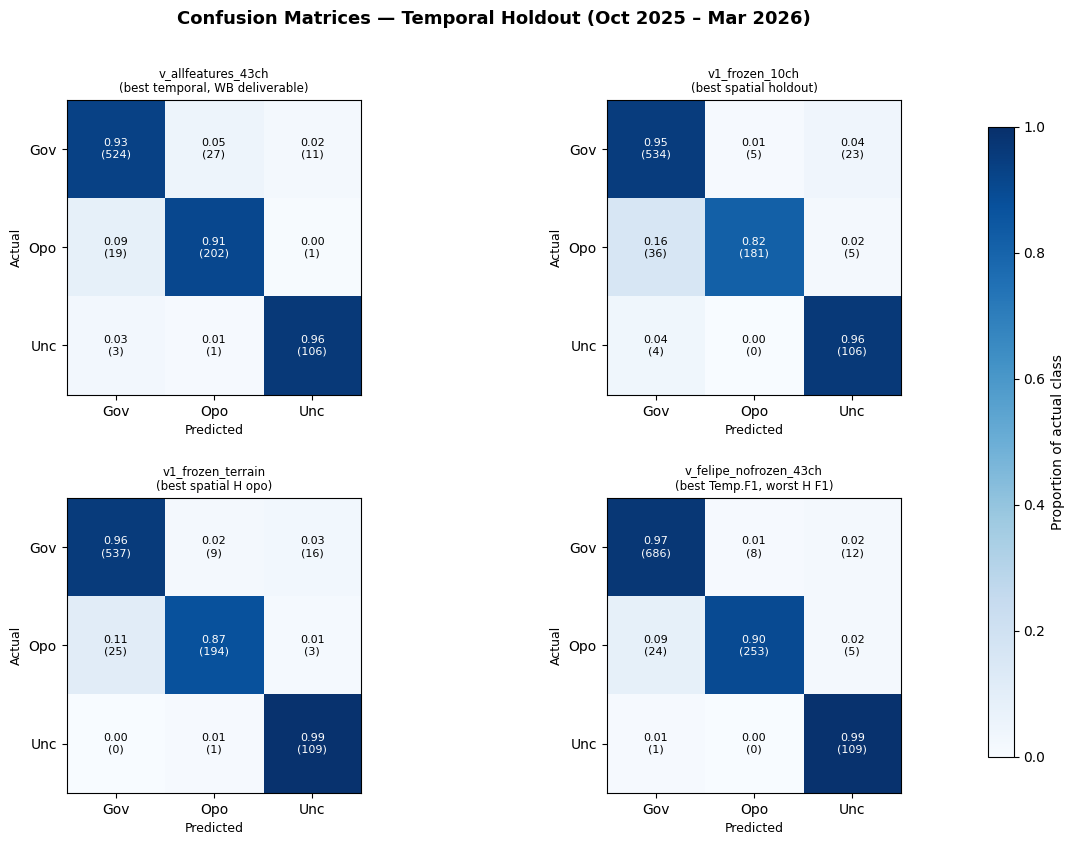

✅ Confusion matrices saved


In [34]:
# ── CELL 5b: Confusion matrices — 4 selected models ──────────────────────────
import matplotlib.pyplot as plt
import numpy as np, ast

ext_df = pd.read_csv(RESULTS_DIR / "temporal_extended_metrics.csv")  # load extended metrics

SELECTED = [
    "v_allfeatures_43ch",         # best temporal inner-join (the WB deliverable)
    "v1_frozen_10ch",             # best spatial holdout (cross-geography baseline)
    "v1_frozen_terrain",          # best spatial opo detection (terrain benefit)
    "v_felipe_nofrozen_43ch",     # best Temp.F1 overall (worst spatial — memorisation example)
]
TITLES = [
    "v_allfeatures_43ch\n(best temporal, WB deliverable)",
    "v1_frozen_10ch\n(best spatial holdout)",
    "v1_frozen_terrain\n(best spatial H opo)",
    "v_felipe_nofrozen_43ch\n(best Temp.F1, worst H F1)",
]
CLASS_LABELS = ["Gov", "Opo", "Unc"]                       # axis tick labels

fig, axes = plt.subplots(2, 2, figsize=(13, 9))            # 2×2 subplot grid
fig.subplots_adjust(right=0.86, hspace=0.35, wspace=0.3)  # leave space on right for colorbar
fig.suptitle("Confusion Matrices — Temporal Holdout (Oct 2025 – Mar 2026)",
             fontsize=13, fontweight="bold")

last_im = None                                             # track the last image for colorbar

for ax, name, title in zip(axes.flat, SELECTED, TITLES):
    row = ext_df[ext_df["model"] == name]                  # get this model's row
    if len(row) == 0:
        ax.set_title(f"{name}\n(not found)"); continue

    cm_raw = row.iloc[0]["cm"]                             # confusion matrix (stored as string or list)
    cm = np.array(ast.literal_eval(cm_raw) if isinstance(cm_raw, str) else cm_raw)

    # Normalise row-wise: each row sums to 1.0 — shows proportion of actual class predicted as each column
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)  # blue heatmap
    ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])        # 3 ticks per axis
    ax.set_xticklabels(CLASS_LABELS)                       # column labels
    ax.set_yticklabels(CLASS_LABELS)                       # row labels
    ax.set_xlabel("Predicted", fontsize=9)                 # x axis label
    ax.set_ylabel("Actual", fontsize=9)                    # y axis label
    ax.set_title(title, fontsize=8.5, pad=6)               # subplot title

    for i in range(3):                                     # annotate every cell
        for j in range(3):
            pct    = cm_norm[i, j]                         # normalised proportion
            count  = int(cm[i, j])                         # raw count
            color  = "white" if pct > 0.55 else "black"   # contrast-safe text colour
            ax.text(j, i, f"{pct:.2f}\n({count})",         # proportion + raw count
                    ha="center", va="center", fontsize=8, color=color)
    last_im = im                                           # keep reference for colorbar

# Add a single shared colorbar in the reserved right-hand space
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])           # [left, bottom, width, height]
fig.colorbar(last_im, cax=cbar_ax, label="Proportion of actual class")  # single clean colorbar

fig.savefig(PROJECT_ROOT / "reports/figures/confusion_matrices_temporal.png",
            dpi=150, bbox_inches="tight")                  # save figure
plt.show()
print("✅ Confusion matrices saved")

## Notebook 06 — Complete Analysis: Temporal Performance, All 19 Models

### The temporal ranking — new models fit the pattern

| Model | Temp.F1 | T.opo | T.unc | Note |
|---|---|---|---|---|
| v_felipe_nofrozen_43ch_terrain | 0.947 | 0.941 | 0.932 | Best overall (focal) |
| v_allfeatures_43ch_lj | 0.936 | 0.889 | 0.908 | Best LJ standard |
| **v_allfeatures_43ch_frozen_lj** | **0.934** | **0.932** | **0.905** | Best spatial + strong temporal |
| v_allfeatures_43ch_frozen | 0.928 | 0.911 | 0.917 | |
| **v_allfeatures_43ch** | **0.923** | **0.894** | **0.930** | **WB deliverable** |

v_allfeatures_43ch_frozen (0.928) and v_allfeatures_43ch_frozen_lj (0.934)
both exceed the discriminative LR version (0.923) in temporal F1. The frozen
encoder does not sacrifice temporal performance — it improves it slightly by
preventing overfitting during training.

v_allfeatures_43ch_frozen_lj is now the dominant model on temporal performance
among the standard-loss models: 0.934 Temp.F1, 0.932 T.opo, 0.905 T.unc.
The frozen encoder raises opo precision to 0.937 (vs 0.878 for discriminative)
at a modest recall cost (0.874 vs 0.910). It is more conservative about
calling a cell opposition, but when it does so, it is almost always correct.

### Precision/recall tradeoff for opposition — complete picture

Frozen encoder models consistently shift toward higher precision, lower recall:

| Model | Opo Precision | Opo Recall | Pattern |
|---|---|---|---|
| v_allfeatures_43ch | 0.878 | 0.910 | High recall — finds most opo |
| v_allfeatures_43ch_frozen | 0.974 | 0.856 | High precision — conservative |
| v_allfeatures_43ch_frozen_lj | 0.937 | 0.874 | Balanced — best of both |
| v1_frozen_10ch | 0.973 | 0.815 | Most conservative |

For humanitarian operations: v_allfeatures_43ch finds more opposition cells
(higher recall) with more false positives. v_allfeatures_43ch_frozen makes
fewer false opo alerts but misses 14% of real opposition cells.

### The LJ models are classified under "Focal loss" in the output — a display bug

The notebook labels LJ-standard models (v_allfeatures_43ch_lj,
v_allfeatures_43ch_frozen_lj, etc.) under "Focal loss" because the code maps
only `inner_join` explicitly and groups all other data_types together. This is
a cosmetic display issue — these models use standard CE+Dice loss and should
be considered a third distinct family: "Left-join standard."

### Recommendation table — updated with new models

| Task | Model | Metric | Value |
|---|---|---|---|
| Monthly maps — primary WB deliverable | **v_allfeatures_43ch** | Temp.F1 | 0.923 |
| Best temporal + spatial balance | **v_allfeatures_43ch_frozen_lj** | H F1 / Temp.F1 | 0.464 / 0.934 |
| Future cross-country extension | v_allfeatures_43ch_frozen_lj | H F1 | 0.464 |
| Transition event detection | v_allfeatures_43ch | Event F1 | 0.522 |
| Highest overall temporal F1 | v_felipe_nofrozen_43ch_terrain | Temp.F1 | 0.947 |